In [57]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score

In [58]:
# Load dataset
digits = load_digits()
X = digits.data
y = digits.target

In [59]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

In [60]:
X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [72]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [73]:
# Logistic Regression
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

# SVM
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

# Neural Network
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)
mlp_model.fit(X_train, y_train)
mlp_pred = mlp_model.predict(X_test)

#Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
#Adaboost
ada_model = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

ada_model.fit(X_train, y_train)

ada_pred = ada_model.predict(X_test)



#catboost
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict(X_test)



Logistic Regression Accuracy: 0.9722222222222222
SVM Accuracy: 0.9805555555555555
MLP Accuracy: 0.9722222222222222
Random Forest Accuracy: 0.975
AdaBoost Accuracy: 0.8555555555555555
CatBoost Accuracy: 0.9833333333333333


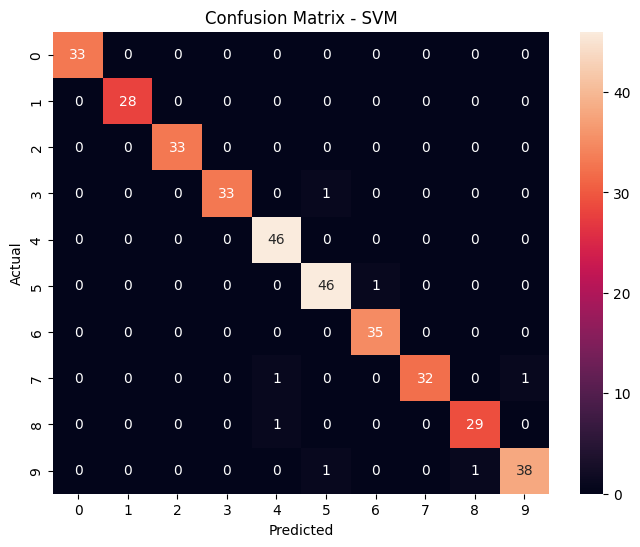

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      0.97      0.99        34
           4       0.96      1.00      0.98        46
           5       0.96      0.98      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.94      0.97        34
           8       0.97      0.97      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [74]:
# Accuracy comparison
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("MLP Accuracy:", accuracy_score(y_test, mlp_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("AdaBoost Accuracy:", accuracy_score(y_test, ada_pred))
print("CatBoost Accuracy:", accuracy_score(y_test, cat_pred))

# Confusion Matrix for Best Model (example: SVM)
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_test, svm_pred))

In [75]:
def calculate_specificity(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)
    
    FP = cm.sum(axis=0) - np.diag(cm)
    FN = cm.sum(axis=1) - np.diag(cm)
    TP = np.diag(cm)
    TN = cm.sum() - (FP + FN + TP)

    specificity = TN / (TN + FP)
    
    return np.mean(specificity)

In [76]:
from sklearn.metrics import confusion_matrix
import numpy as np

def specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    spec = []
    
    for i in range(len(cm)):
        tn = np.sum(cm) - (np.sum(cm[i,:]) + np.sum(cm[:,i]) - cm[i,i])
        fp = np.sum(cm[:,i]) - cm[i,i]
        spec.append(tn / (tn + fp))
        
    return np.mean(spec)

In [80]:
models = {
    "Logistic Regression": log_pred,
    "SVM": svm_pred,
    "Random Forest": rf_pred,
    "AdaBoost": ada_pred,
    "CatBoost": cat_pred
}

results = []

for name, pred in models.items():
    
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='macro')
    rec = recall_score(y_test, pred, average='macro')
    f1 = f1_score(y_test, pred, average='macro')
    spec = specificity(y_test, pred)
    
    # ROC-AUC (multiclass)
    try:
        roc = roc_auc_score(y_test, pred, multi_class='ovr')
    except:
        roc = None

    results.append([name, acc, prec, rec, f1, spec, roc])

In [83]:
columns = [
"Model",
"Accuracy",
"Precision",
"Recall",
"F1 Score",
"Specificity",
"ROC AUC"
]

results_df = pd.DataFrame(results, columns=columns)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score  Specificity  \
0  Logistic Regression  0.972222   0.973720  0.974370  0.973967     0.996885   
1                  SVM  0.980556   0.982991  0.980715  0.981652     0.997801   
2        Random Forest  0.975000   0.976721  0.974436  0.975235     0.997194   
3             AdaBoost  0.855556   0.850676  0.850682  0.846847     0.984059   
4             CatBoost  0.983333   0.983796  0.984133  0.983885     0.998141   

  ROC AUC  
0    None  
1    None  
2    None  
3    None  
4    None  
